In [1]:
import pandas as pd
import numpy as np
import plotly.express as px


In [2]:
film = pd.read_csv("data/Revenue and Film performance.csv")

customer = pd.read_csv("data/Customer Behaviour and Retention.csv")

monthly = pd.read_csv("data/Time based business trend.csv")

staff = pd.read_csv("data/Store and staff Performance.csv")

geographic = pd.read_csv("data/Geographic and market analysis.csv")

inventory = pd.read_csv("data/Inventory and operation.csv")

In [3]:
print(film.shape)
print(customer.shape)
print(monthly.shape)
print(staff.shape)
print(geographic.shape)
print(inventory.shape)


(1000, 7)
(599, 9)
(4, 6)
(2, 6)
(597, 6)
(958, 8)


In [4]:
print(film.columns)
print(customer.columns)
print(monthly.columns)
print(staff.columns)
print(geographic.columns)
print(inventory.columns)

Index(['film_id', 'film_title', 'category', 'total_rental_revenue',
       'total_rentals', 'avg_revenue_per_rental', 'last_rental_date'],
      dtype='str')
Index(['customer_id', 'full_name', 'country', 'city', 'total_amount_spent',
       'total_rentals', 'first_rental_date', 'most_recent_rental_date',
       'rental_month'],
      dtype='str')
Index(['year', 'month', 'total_rentals', 'total_revenue', 'unique_customers',
       'avg_revenue_per_rental'],
      dtype='str')
Index(['store_id', 'staff_name', 'total_rental_processed',
       'total_revenue_collected', 'unique_customer_served',
       'avg_rentals_per_day'],
      dtype='str')
Index(['country', 'city', 'total_rentals', 'total_revenue', 'unique_customers',
       'most_popular_film_category'],
      dtype='str')
Index(['film_id', 'film_title', 'category', 'inventory_count', 'total_rentals',
       'total_revenue', 'last_rental_date', 'avg_rental_duration'],
      dtype='str')


In [5]:
print(film.dtypes)
print(customer.dtypes)
print(monthly.dtypes)
print(staff.dtypes)
print(geographic.dtypes)
print(inventory.dtypes)

film_id                     int64
film_title                    str
category                      str
total_rental_revenue      float64
total_rentals               int64
avg_revenue_per_rental    float64
last_rental_date              str
dtype: object
customer_id                  int64
full_name                      str
country                        str
city                           str
total_amount_spent         float64
total_rentals                int64
first_rental_date              str
most_recent_rental_date        str
rental_month                 int64
dtype: object
year                        int64
month                       int64
total_rentals               int64
total_revenue             float64
unique_customers            int64
avg_revenue_per_rental    float64
dtype: object
store_id                     int64
staff_name                     str
total_rental_processed       int64
total_revenue_collected    float64
unique_customer_served       int64
avg_rentals_per_day       

In [6]:
# function to clean the column names 

def clean_columns(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df

In [7]:
film = clean_columns(film)
customer = clean_columns(customer)
monthly = clean_columns(monthly)
staff = clean_columns(staff)
geographic = clean_columns(geographic)
inventory = clean_columns(inventory)

In [8]:
# Converts dates
# For film
film["last_rental_date"] = pd.to_datetime(film["last_rental_date"])

# for customers
customer["first_rental_date"] = pd.to_datetime(customer["first_rental_date"])

customer["most_recent_rental_date"] = pd.to_datetime(
    customer["most_recent_rental_date"]
)

# For inventory
inventory["last_rental_date"] = pd.to_datetime(
    inventory["last_rental_date"]
)

In [9]:
# Check missing values 
print(film.isnull().sum())
print(customer.isnull().sum())
print(monthly.isnull().sum())
print(staff.isnull().sum())
print(geographic.isnull().sum())
print(inventory.isnull().sum())

film_id                    0
film_title                 0
category                   0
total_rental_revenue      42
total_rentals              0
avg_revenue_per_rental    42
last_rental_date          42
dtype: int64
customer_id                0
full_name                  0
country                    0
city                       0
total_amount_spent         0
total_rentals              0
first_rental_date          0
most_recent_rental_date    0
rental_month               0
dtype: int64
year                      0
month                     0
total_rentals             0
total_revenue             0
unique_customers          0
avg_revenue_per_rental    0
dtype: int64
store_id                   0
staff_name                 0
total_rental_processed     0
total_revenue_collected    0
unique_customer_served     0
avg_rentals_per_day        0
dtype: int64
country                       0
city                          0
total_rentals                 0
total_revenue                 0
unique_custome

In [10]:
# Check for duplicate
print(film.duplicated().sum())
print(customer.duplicated().sum())
print(monthly.duplicated().sum())
print(staff.duplicated().sum())
print(geographic.duplicated().sum())
print(inventory.duplicated().sum())

0
0
0
0
0
0


In [11]:
# Check the important IDs to be unique
print(film["film_id"].is_unique)
print(customer["customer_id"].is_unique)
print(inventory["film_id"].is_unique)
print(geographic[["country", "city"]].duplicated().sum())
print(staff["store_id"].is_unique)

True
True
True
0
True


In [12]:
# creating the film master dataset
inventory_info = inventory[
    ["film_id", "inventory_count", "avg_rental_duration"]
]

film_master = film.merge(
    inventory_info,
    on="film_id",
    how="left"
)

In [13]:
film_master.shape

(1000, 9)

In [14]:
film_master.isnull().sum()

film_id                    0
film_title                 0
category                   0
total_rental_revenue      42
total_rentals              0
avg_revenue_per_rental    42
last_rental_date          42
inventory_count           42
avg_rental_duration       42
dtype: int64

In [15]:
film_master.head()

,film_id,film_title,category,total_rental_revenue,total_rentals,avg_revenue_per_rental,last_rental_date,inventory_count,avg_rental_duration
0,943,Villain Desperate,Documentary,NaN,0,NaN,NaT,NaN,NaN
1,148,Chocolate Duck,Foreign,NaN,0,NaN,NaT,NaN,NaN
2,33,Apollo Teen,Drama,NaN,0,NaN,NaT,NaN,NaN
3,386,Gump Date,Travel,NaN,0,NaN,NaT,NaN,NaN
4,607,Muppet Mile,Foreign,NaN,0,NaN,NaT,NaN,NaN


In [16]:
# Handling missing inventory
film_master["inventory_count"] = film_master["inventory_count"].fillna(0)

In [17]:
film_master.head()

,film_id,film_title,category,total_rental_revenue,total_rentals,avg_revenue_per_rental,last_rental_date,inventory_count,avg_rental_duration
0,943,Villain Desperate,Documentary,NaN,0,NaN,NaT,0.0,NaN
1,148,Chocolate Duck,Foreign,NaN,0,NaN,NaT,0.0,NaN
2,33,Apollo Teen,Drama,NaN,0,NaN,NaT,0.0,NaN
3,386,Gump Date,Travel,NaN,0,NaN,NaT,0.0,NaN
4,607,Muppet Mile,Foreign,NaN,0,NaN,NaT,0.0,NaN


In [18]:
film_master['total_rental_revenue'] = film_master['total_rental_revenue'].fillna(0)
film_master['avg_revenue_per_rental'] = film_master['avg_revenue_per_rental'].fillna(0)


print("Missing values in film_master handled (Revenue metrics filled with 0).")
print("Remaining nulls in film_master:\n", film_master.isnull().sum())

Missing values in film_master handled (Revenue metrics filled with 0).
Remaining nulls in film_master:
 film_id                    0
film_title                 0
category                   0
total_rental_revenue       0
total_rentals              0
avg_revenue_per_rental     0
last_rental_date          42
inventory_count            0
avg_rental_duration       42
dtype: int64


In [19]:
monthly.head()

,year,month,total_rentals,total_revenue,unique_customers,avg_revenue_per_rental
0,2007,2,2016,8351.84,518,4.142778
1,2007,3,5644,23886.56,599,4.232204
2,2007,4,6752,28559.46,599,4.229778
3,2007,5,182,514.18,158,2.825165


In [20]:
monthly.describe()

,year,month,total_rentals,total_revenue,unique_customers,avg_revenue_per_rental
count,4.0,4.000000,4.00000,4.000000,4.00000,4.000000
mean,2007.0,3.500000,3648.50000,15328.010000,468.50000,3.857481
std,0.0,1.290994,3071.12417,13120.423702,210.49228,0.689467
min,2007.0,2.000000,182.00000,514.180000,158.00000,2.825165
25%,2007.0,2.750000,1557.50000,6392.425000,428.00000,3.813375
50%,2007.0,3.500000,3830.00000,16119.200000,558.50000,4.186278
75%,2007.0,4.250000,5921.00000,25054.785000,599.00000,4.230384
max,2007.0,5.000000,6752.00000,28559.460000,599.00000,4.232204


In [21]:
customer.columns

Index(['customer_id', 'full_name', 'country', 'city', 'total_amount_spent',
       'total_rentals', 'first_rental_date', 'most_recent_rental_date',
       'rental_month'],
      dtype='str')

In [22]:
print("="*50)
print("PART 2.2: DATA UNDERSTANDING SUMMARY")
print("="*50)

print("\n1. RECORDS & COLUMNS:")
print(f"   - Film Master:      {film_master.shape[0]} records, {film_master.shape[1]} columns")
print(f"   - Customer:         {customer.shape[0]} records, {customer.shape[1]} columns")
print(f"   - Monthly Trends:   {monthly.shape[0]} records, {monthly.shape[1]} columns")
print(f"   - Store & Staff:    {staff.shape[0]} records, {staff.shape[1]} columns")
print(f"   - Geographic:       {geographic.shape[0]} records, {geographic.shape[1]} columns")


PART 2.2: DATA UNDERSTANDING SUMMARY

1. RECORDS & COLUMNS:
   - Film Master:      1000 records, 9 columns
   - Customer:         599 records, 9 columns
   - Monthly Trends:   4 records, 6 columns
   - Store & Staff:    2 records, 6 columns
   - Geographic:       597 records, 6 columns


In [23]:
# 1. Calculate average payment per transaction (Total spent / Total rentals)
customer['avg_payment_per_txn'] = customer['total_amount_spent'] / customer['total_rentals']

print("=== 1. DISTRIBUTION OF RENTAL REVENUE (Per Customer) ===")
print(customer['total_amount_spent'].describe())

print("\n=== 2. DISTRIBUTION OF RENTALS (Per Customer) ===")
print(customer['total_rentals'].describe())

print("\n=== 3. DISTRIBUTION OF RENTAL DURATION (Per Film) ===")
print(film_master['avg_rental_duration'].describe())

print("\n=== 4. DISTRIBUTION OF PAYMENTS PER TRANSACTION ===")
print(customer['avg_payment_per_txn'].describe())

=== 1. DISTRIBUTION OF RENTAL REVENUE (Per Customer) ===
count    599.000000
mean     102.357329
std       25.226628
min       27.930000
25%       85.770000
50%       99.740000
75%      117.240000
max      211.550000
Name: total_amount_spent, dtype: float64

=== 2. DISTRIBUTION OF RENTALS (Per Customer) ===
count    599.000000
mean      24.360601
std        5.092474
min        7.000000
25%       21.000000
50%       24.000000
75%       28.000000
max       45.000000
Name: total_rentals, dtype: float64

=== 3. DISTRIBUTION OF RENTAL DURATION (Per Film) ===
count    958.000000
mean       4.524648
std        0.748112
min        1.666667
25%        4.043750
50%        4.545455
75%        5.000000
max        6.875000
Name: avg_rental_duration, dtype: float64

=== 4. DISTRIBUTION OF PAYMENTS PER TRANSACTION ===
count    599.000000
mean       4.198002
std        0.492671
min        2.779474
25%        3.875621
50%        4.198333
75%        4.568947
max        5.619630
Name: avg_payment_per_txn

## Analysis & Visualization 

In [24]:
# top 10 movies by revenue
top_films = film_master.sort_values(
    "total_rental_revenue",
    ascending=False
).head(10)

top_films[
    [
        "film_title",
        "category",
        "total_rental_revenue",
        "total_rentals"
    ]
]

,film_title,category,total_rental_revenue,total_rentals
42,Telegraph Voyage,Music,215.75,27
43,Zorro Ark,Comedy,199.72,31
44,Wife Turn,Documentary,198.73,31
45,Innocent Usual,Foreign,191.74,26
46,Hustler Party,Comedy,190.78,22
47,Saturday Lambs,Sports,190.74,28
48,Titans Jerk,Sci-Fi,186.73,29
49,Harry Idaho,Drama,177.73,30
50,Torque Bound,Drama,169.76,27
51,Dogma Family,Animation,168.72,30


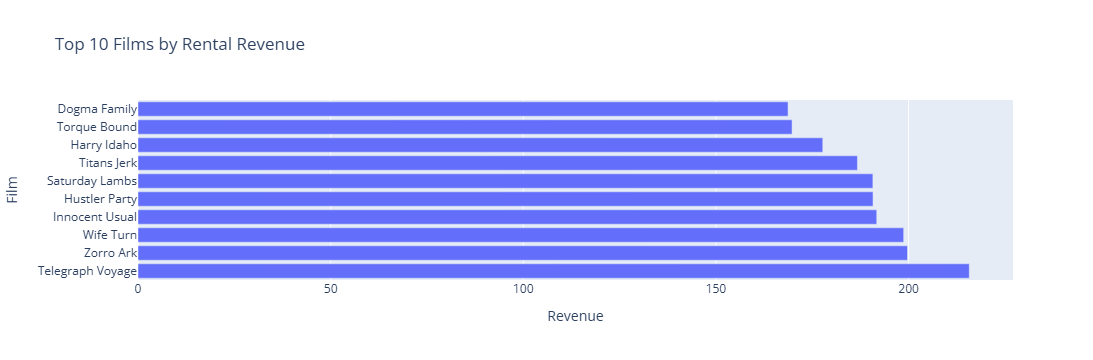

In [25]:
fig = px.bar(
    top_films,
    x="total_rental_revenue",
    y="film_title",
    orientation="h",
    title="Top 10 Films by Rental Revenue",
    labels={
        "total_rental_revenue": "Revenue",
        "film_title": "Film"
    }
)

fig.show()

In [26]:
# top 10 most rented movies 
most_rented = film_master.sort_values(
    "total_rentals",
    ascending=False
).head(10)

most_rented[
    [
        "film_title",
        "category",
        "total_rentals",
        "total_rental_revenue"
    ]
]

,film_title,category,total_rentals,total_rental_revenue
66,Bucket Brotherhood,Travel,34,150.72
224,Rocketeer Mother,Foreign,33,97.72
285,Juggler Hardly,Animation,32,86.71
60,Scalawag Duck,Music,32,157.71
205,Forward Temple,Games,32,102.74
165,Ridgemont Submarine,New,32,110.72
225,Grit Clockwork,Games,32,97.72
312,Rush Goodfellas,Family,31,81.72
43,Zorro Ark,Comedy,31,199.72
53,Goodfellas Salute,Sci-Fi,31,164.75


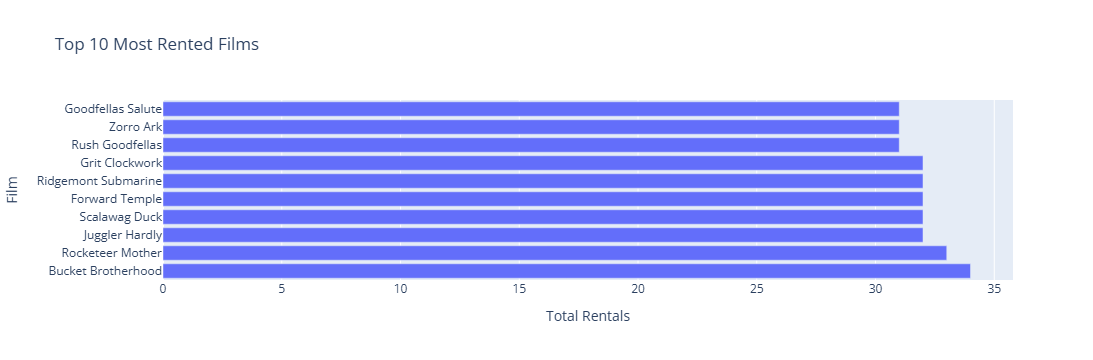

In [27]:
fig = px.bar(
    most_rented,
    x="total_rentals",
    y="film_title",
    orientation="h",
    title="Top 10 Most Rented Films",
    labels={
        "total_rentals": "Total Rentals",
        "film_title": "Film"
    }
)

fig.show()

## Category performance 

In [28]:
category_performance = film_master.groupby("category").agg(
    total_revenue=("total_rental_revenue", "sum"),
    total_rentals=("total_rentals", "sum"),
    number_of_films=("film_id", "count")
).reset_index()

In [29]:
category_performance = category_performance.sort_values(
    "total_revenue",
    ascending=False
)

category_performance

,category,total_revenue,total_rentals,number_of_films
14,Sports,4892.19,1179,74
13,Sci-Fi,4336.01,1101,61
1,Animation,4245.31,1166,66
6,Drama,4118.46,1060,62
4,Comedy,4002.48,941,58
12,New,3966.38,940,63
0,Action,3951.84,1112,64
8,Foreign,3934.47,1033,73
9,Games,3922.18,969,61
7,Family,3830.15,1096,69


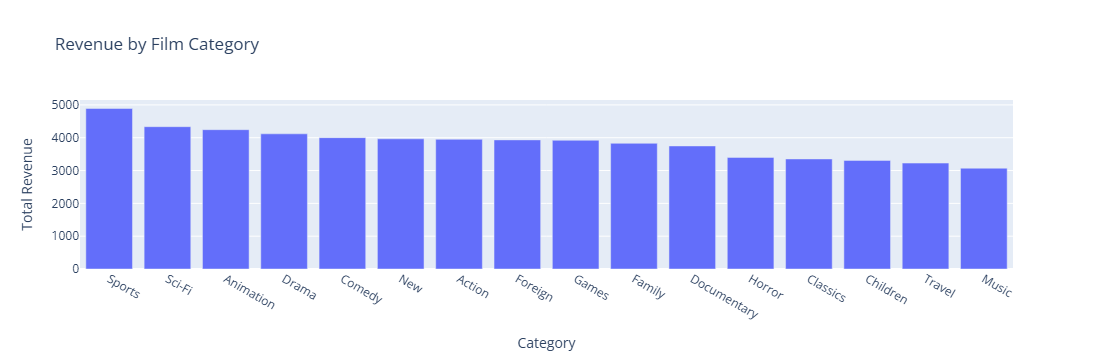

In [30]:
fig = px.bar(
    category_performance,
    x="category",
    y="total_revenue",
    title="Revenue by Film Category",
    labels={
        "category": "Category",
        "total_revenue": "Total Revenue"
    }
)

fig.show()

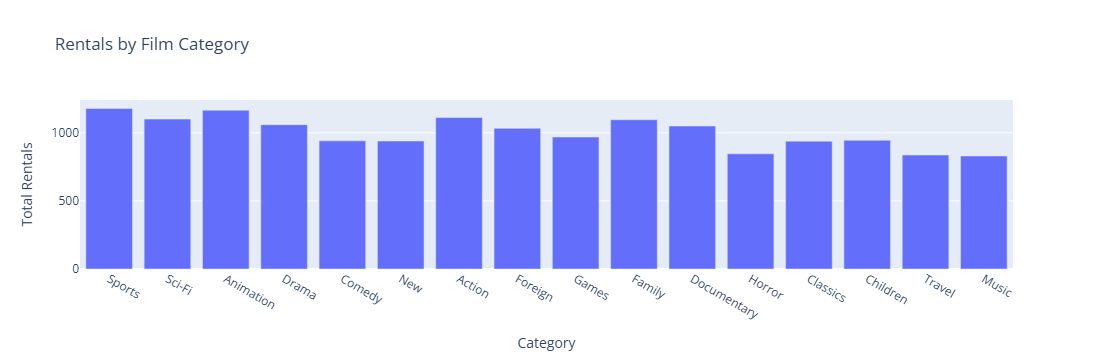

In [31]:
# Rentals by categories 
fig = px.bar(
    category_performance,
    x="category",
    y="total_rentals",
    title="Rentals by Film Category",
    labels={
        "category": "Category",
        "total_rentals": "Total Rentals"
    }
)

fig.show()

## Monthly revenue trends 


In [32]:
monthly.head()

,year,month,total_rentals,total_revenue,unique_customers,avg_revenue_per_rental
0,2007,2,2016,8351.84,518,4.142778
1,2007,3,5644,23886.56,599,4.232204
2,2007,4,6752,28559.46,599,4.229778
3,2007,5,182,514.18,158,2.825165


In [33]:
monthly["date"] = pd.to_datetime(
    monthly["year"].astype(str)
    + "-"
    + monthly["month"].astype(str)
    + "-01"
)

In [34]:
monthly = monthly.sort_values("date")

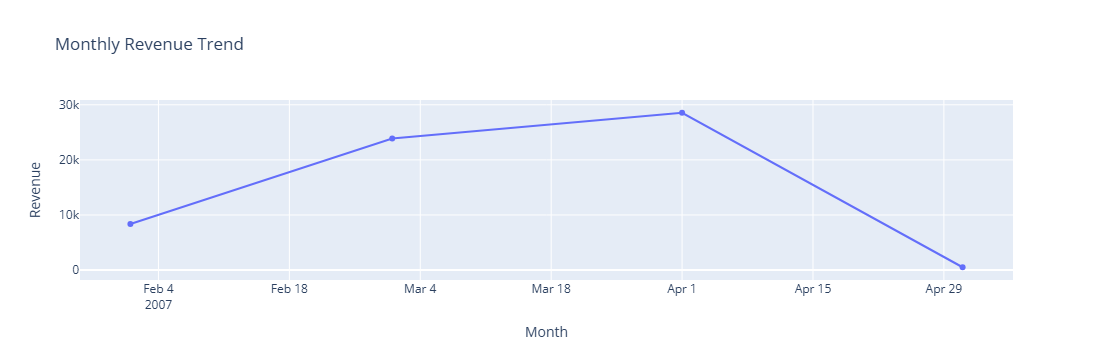

In [35]:
fig = px.line(
    monthly,
    x="date",
    y="total_revenue",
    title="Monthly Revenue Trend",
    labels={
        "date": "Month",
        "total_revenue": "Revenue"
    },
    markers=True
)

fig.show()

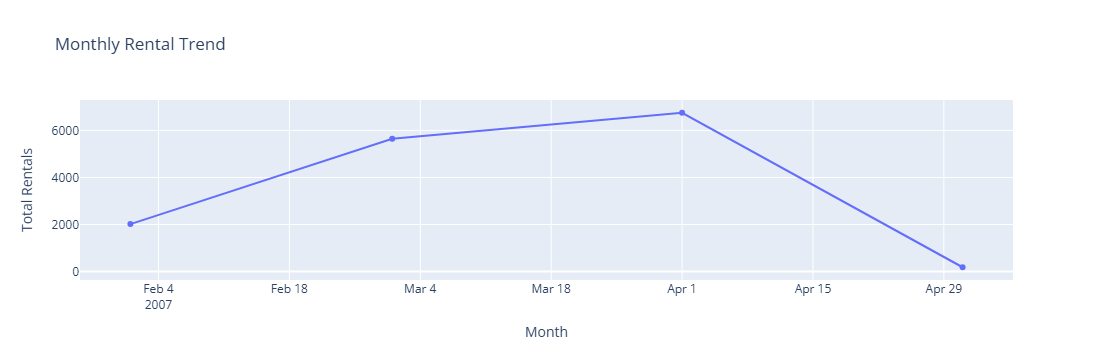

In [36]:
# Monthly rental trends
fig = px.line(
    monthly,
    x="date",
    y="total_rentals",
    title="Monthly Rental Trend",
    labels={
        "date": "Month",
        "total_rentals": "Total Rentals"
    },
    markers=True
)

fig.show()

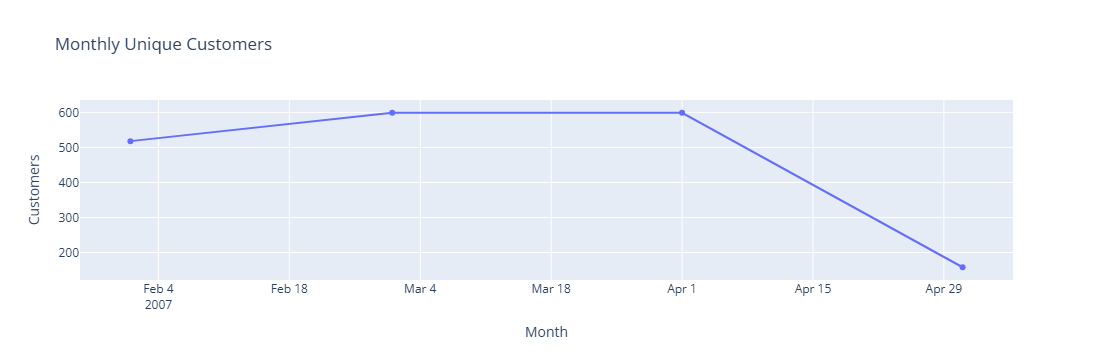

In [37]:
# Monthly unique customers 
fig = px.line(
    monthly,
    x="date",
    y="unique_customers",
    title="Monthly Unique Customers",
    labels={
        "date": "Month",
        "unique_customers": "Customers"
    },
    markers=True
)

fig.show()

## Customer Behaviours

In [38]:
# Top customers by spending

top_customers = customer.sort_values(
    "total_amount_spent",
    ascending=False
).head(10)

top_customers[
    [
        "full_name",
        "country",
        "city",
        "total_amount_spent",
        "total_rentals"
    ]
]

,full_name,country,city,total_amount_spent,total_rentals
0,Eleanor Hunt,Runion,Saint-Denis,211.55,45
1,Karl Seal,United States,Cape Coral,208.58,42
2,Marion Snyder,Brazil,Santa Brbara dOeste,194.61,39
3,Rhonda Kennedy,Netherlands,Apeldoorn,191.62,38
4,Clara Shaw,Belarus,Molodetno,189.60,40
5,Tommy Collazo,Iran,Qomsheh,183.63,37
6,Ana Bradley,United States,Memphis,167.67,33
7,Curtis Irby,Canada,Richmond Hill,167.62,38
8,Marcia Dean,Philippines,Tanza,166.61,39
9,Mike Way,India,Valparai,162.67,33


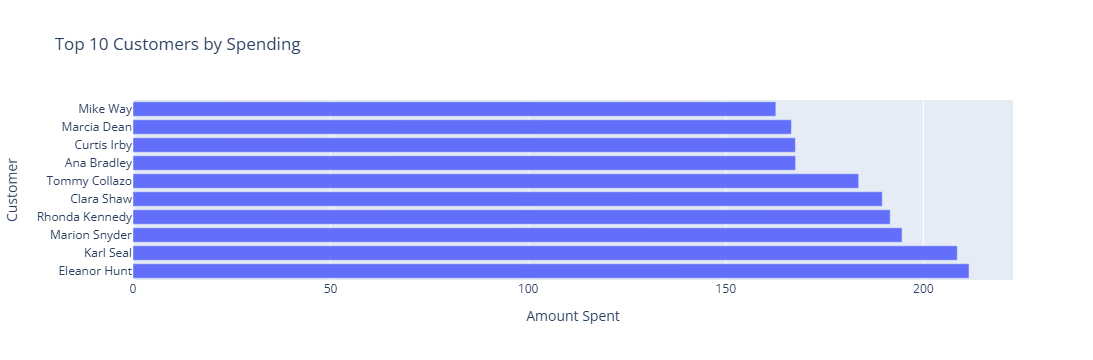

In [39]:
fig = px.bar(
    top_customers,
    x="total_amount_spent",
    y="full_name",
    orientation="h",
    title="Top 10 Customers by Spending",
    labels={
        "total_amount_spent": "Amount Spent",
        "full_name": "Customer"
    }
)

fig.show()

In [40]:
# Top customers by rentals
top_renting_customers = customer.sort_values(
    "total_rentals",
    ascending=False
).head(10)

top_renting_customers[
    [
        "full_name",
        "total_rentals",
        "total_amount_spent"
    ]
]

,full_name,total_rentals,total_amount_spent
0,Eleanor Hunt,45,211.55
1,Karl Seal,42,208.58
4,Clara Shaw,40,189.60
8,Marcia Dean,39,166.61
22,Tammy Sanders,39,149.61
2,Marion Snyder,39,194.61
7,Curtis Irby,38,167.62
3,Rhonda Kennedy,38,191.62
5,Tommy Collazo,37,183.63
29,Brandon Huey,36,145.64


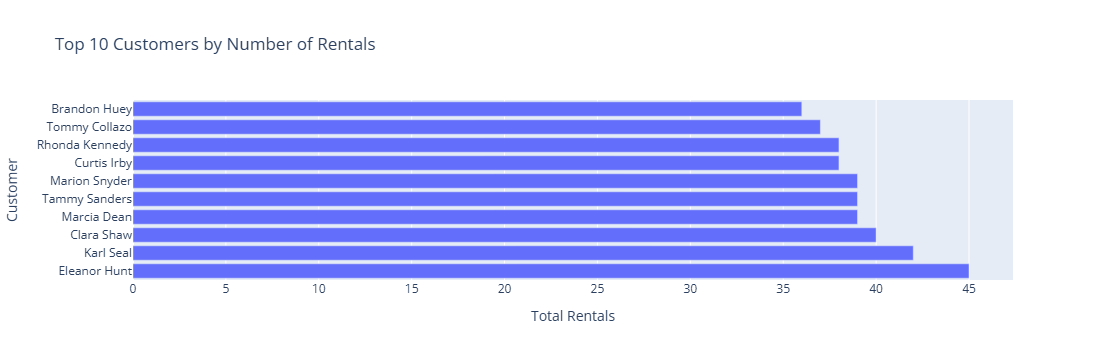

In [41]:
fig = px.bar(
    top_renting_customers,
    x="total_rentals",
    y="full_name",
    orientation="h",
    title="Top 10 Customers by Number of Rentals",
    labels={
        "total_rentals": "Total Rentals",
        "full_name": "Customer"
    }
)

fig.show()

## Geographic Analysis

In [42]:
# Top cities by revenue
top_cities = geographic.sort_values(
    "total_revenue",
    ascending=False
).head(10)

top_cities[
    [
        "city",
        "country",
        "total_revenue",
        "total_rentals",
        "unique_customers"
    ]
]

,city,country,total_revenue,total_rentals,unique_customers
0,Saint-Denis,Runion,211.55,45,1
1,Cape Coral,United States,208.58,42,1
2,Santa Brbara dOeste,Brazil,194.61,39,1
3,Apeldoorn,Netherlands,191.62,38,1
4,Molodetno,Belarus,189.60,40,1
5,Qomsheh,Iran,183.63,37,1
6,London,United Kingdom,174.54,46,2
7,Memphis,United States,167.67,33,1
8,Richmond Hill,Canada,167.62,38,1
9,Tanza,Philippines,166.61,39,1


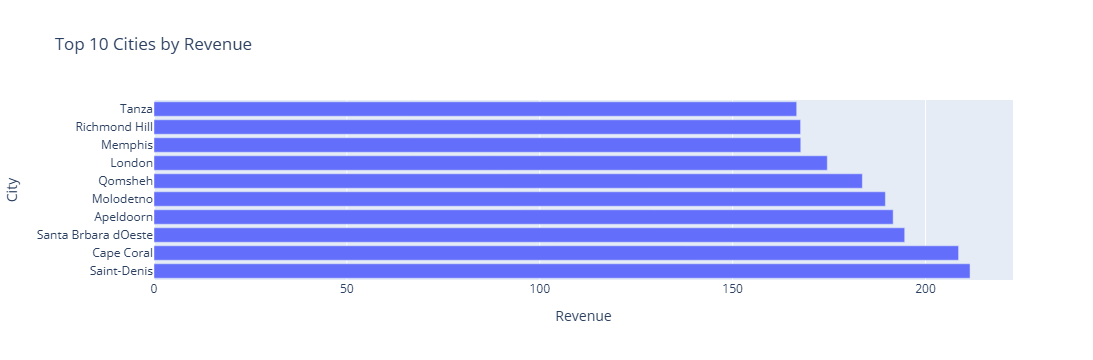

In [43]:
fig = px.bar(
    top_cities,
    x="total_revenue",
    y="city",
    orientation="h",
    title="Top 10 Cities by Revenue",
    labels={
        "total_revenue": "Revenue",
        "city": "City"
    }
)

fig.show()

In [44]:
# Country Performance
country_performance = geographic.groupby("country").agg(
    total_revenue=("total_revenue", "sum"),
    total_rentals=("total_rentals", "sum"),
    unique_customers=("unique_customers", "sum")
).reset_index()

In [45]:
country_performance = country_performance.sort_values(
    "total_revenue",
    ascending=False
)

country_performance.head(10)

,country,total_revenue,total_rentals,unique_customers
42,India,6032.79,1421,60
21,China,5247.04,1296,53
101,United States,3694.27,869,36
48,Japan,3121.52,748,31
58,Mexico,2984.82,718,30
13,Brazil,2919.19,681,28
78,Russian Federation,2765.62,638,28
73,Philippines,2219.70,530,20
95,Turkey,1498.49,351,15
43,Indonesia,1352.69,331,14


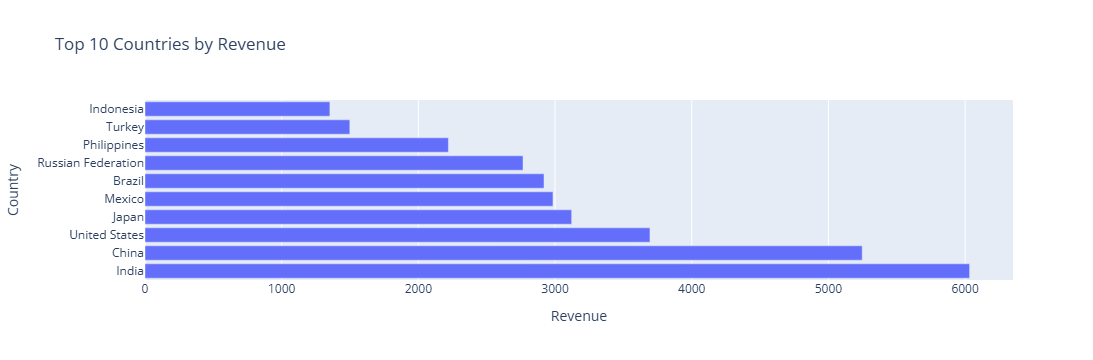

In [46]:
top_countries = country_performance.head(10)

fig = px.bar(
    top_countries,
    x="total_revenue",
    y="country",
    orientation="h",
    title="Top 10 Countries by Revenue",
    labels={
        "total_revenue": "Revenue",
        "country": "Country"
    }
)

fig.show()

## Staff and Store Performance

In [47]:
staff_performance = staff.sort_values(
    "total_revenue_collected",
    ascending=False
)

staff_performance[
    [
        "staff_name",
        "total_rental_processed",
        "total_revenue_collected",
        "unique_customer_served"
    ]
    ]
# staff_performance.head()

,staff_name,total_rental_processed,total_revenue_collected,unique_customer_served
1,Jon Stephens,7265,30813.33,599
0,Mike Hillyer,7327,30498.71,599


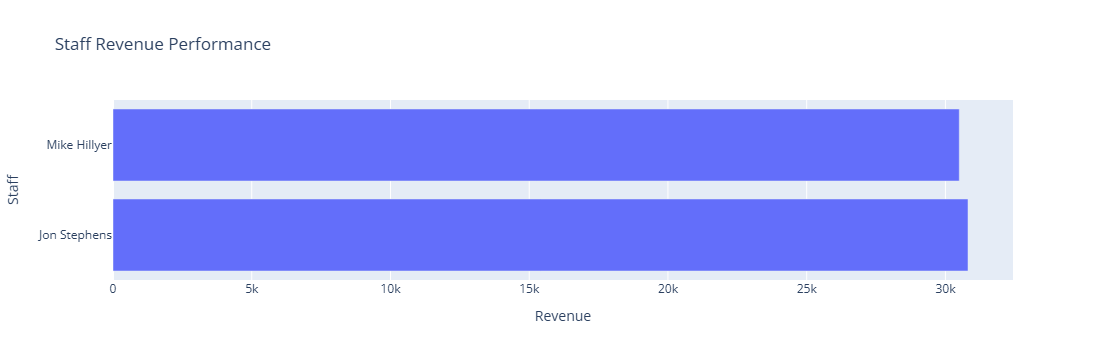

In [48]:
fig = px.bar(
    staff_performance,
    x="total_revenue_collected",
    y="staff_name",
    orientation="h",
    title="Staff Revenue Performance",
    labels={
        "total_revenue_collected": "Revenue",
        "staff_name": "Staff"
    }
)

fig.show()

In [49]:
# Store Performance 
store_performance = staff.groupby("store_id").agg(
    total_revenue=("total_revenue_collected", "sum"),
    total_rentals=("total_rental_processed", "sum"),
    unique_customers=("unique_customer_served", "sum")
).reset_index()

In [50]:
store_performance

,store_id,total_revenue,total_rentals,unique_customers
0,1,30498.71,7327,599
1,2,30813.33,7265,599


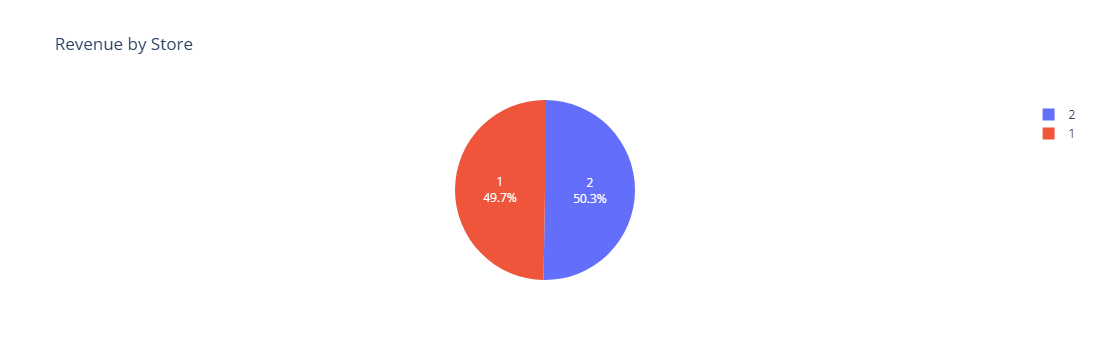

In [51]:
fig = px.pie(
    store_performance,
    names="store_id",
    values="total_revenue",
    title="Revenue by Store",
    labels={
        "store_id": "Store",
        "total_revenue": "Revenue"
    }
)

fig.update_traces(textposition="inside", textinfo="percent+label")
fig.show()

## Inventory Analysis

In [52]:
#  Film with the highest inventory
high_inventory = inventory.sort_values(
    "inventory_count",
    ascending=False
).head(10)

high_inventory[
    [
        "film_title",
        "category",
        "inventory_count",
        "total_rentals"
    ]
]

,film_title,category,inventory_count,total_rentals
26,Trip Newton,Action,8,26
0,Juggler Hardly,Animation,8,29
25,Loathing Legally,Classics,8,26
24,Gleaming Jawbreaker,Sports,8,27
13,Primary Glass,Action,8,27
12,Frost Head,Classics,8,28
11,Rocketeer Mother,Foreign,8,28
10,Apache Divine,Family,8,28
8,Zorro Ark,Comedy,8,28
9,Ridgemont Submarine,New,8,28


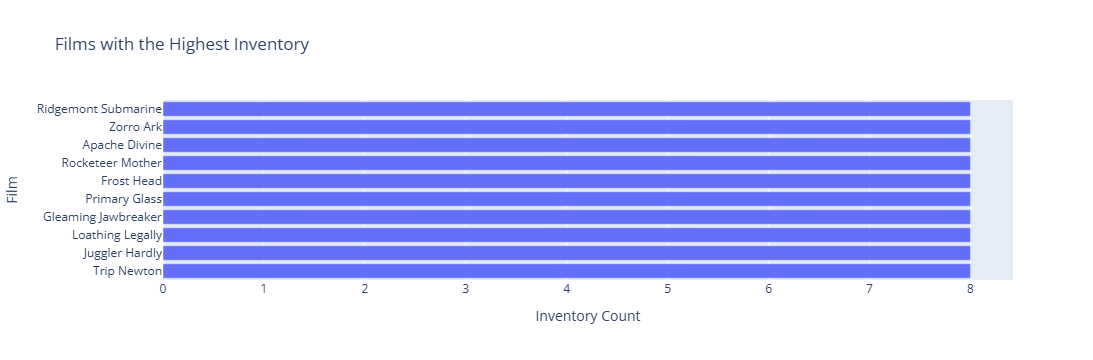

In [53]:
fig = px.bar(
    high_inventory,
    x="inventory_count",
    y="film_title",
    orientation="h",
    title="Films with the Highest Inventory",
    labels={
        "inventory_count": "Inventory Count",
        "film_title": "Film"
    }
)

fig.show()

In [54]:
# Film with the lowest rental demand
low_demand = inventory.sort_values(
    "total_rentals"
).head(10)

low_demand[
    [
        "film_title",
        "category",
        "inventory_count",
        "total_rentals"
    ]
]

,film_title,category,inventory_count,total_rentals
957,Hardly Robbers,Documentary,2,4
956,Mixed Doors,Foreign,2,4
955,Train Bunch,Horror,2,4
954,Braveheart Human,Family,2,5
953,Hunter Alter,Documentary,2,5
952,Informer Double,Foreign,2,5
951,Doctor Grail,Children,2,5
947,Mussolini Spoilers,Sports,2,5
936,Bunch Minds,Drama,2,5
937,Fever Empire,Games,2,5


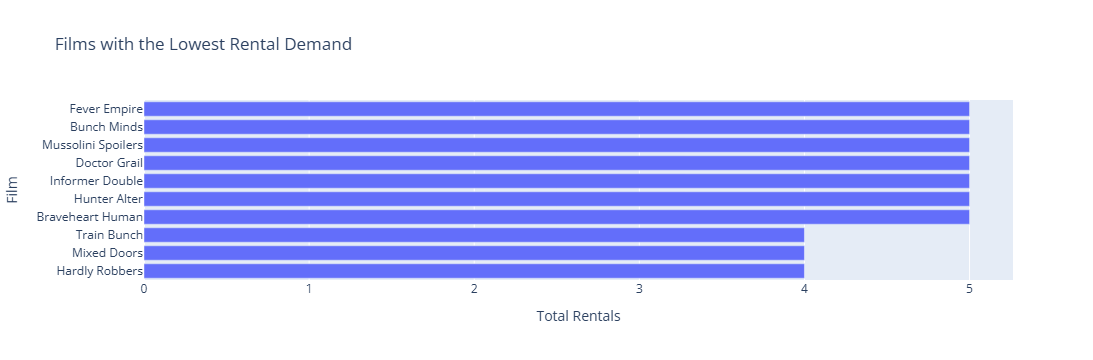

In [55]:
fig = px.bar(
    low_demand,
    x="total_rentals",
    y="film_title",
    orientation="h",
    title="Films with the Lowest Rental Demand",
    labels={
        "total_rentals": "Total Rentals",
        "film_title": "Film"
    }
)

fig.show()

## Business Validation

In [56]:
print("Film revenue:", film_master["total_rental_revenue"].sum())
print("Customer revenue:", customer["total_amount_spent"].sum())
print("Staff revenue:", staff["total_revenue_collected"].sum())
print("Inventory revenue:", inventory["total_revenue"].sum())

Film revenue: 61312.04
Customer revenue: 61312.03999999999
Staff revenue: 61312.04
Inventory revenue: 61312.04


In [57]:
# Rental counts validation
print("Film rentals:", film_master["total_rentals"].sum())
print("Customer rentals:", customer["total_rentals"].sum())
print("Staff rentals:", staff["total_rental_processed"].sum())
print("Inventory rentals:", inventory["total_rentals"].sum())

Film rentals: 16044
Customer rentals: 14592
Staff rentals: 14592
Inventory rentals: 14592


In [60]:
## Export the clean analysis dataset 
film_master.to_csv("film_master_clean.csv", index=False)

category_performance.to_csv(
    "category_performance.csv",
    index=False
)

country_performance.to_csv(
    "country_performance.csv",
    index=False
)

store_performance.to_csv(
    "store_performance.csv",
    index=False
)

monthly.to_csv(
    "monthly_clean.csv",
    index=False
)
customer.to_csv('customer.csv', index=False)
staff.to_csv('staff.csv', index=False)
inventory.to_csv('inventory.csv', index=False)
geographic.to_csv('geographic.csv', index=False)

In [59]:
print("Total Revenue:", film_master["total_rental_revenue"].sum())

Total Revenue: 61312.04
